<a href="https://colab.research.google.com/github/avionerman/neural-networks-msc/blob/main/deepfake_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ανιχνευση Deepfake Εικονων με Convolutional Neural Network

Σε αυτο το notebook φτιαχνω ενα **CNN** που ταξινομει εικονες σε **REAL** (αληθινες) η **FAKE** (AI-generated/deepfake).

**Dataset:** CIFAKE (~120.000 εικονες, 32x32 pixels) - 60k real (απο CIFAR-10) και 60k AI-generated με Stable Diffusion.

**Βηματα:**
1. Ελεγχος GPU
2. Φορτωση δεδομενων
3. Εξερευνηση δειγματων
4. Προεπεξεργασια
5. Κατασκευη του CNN (baseline)
6. Εκπαιδευση baseline
7. Καμπυλες εκπαιδευσης
8. Αξιολογηση στο test set
9. Confusion matrix
10. Παραδειγματα προβλεψεων
11. Hyperparameter Tuning με Keras Tuner
12. Εκπαιδευση τελικου custom CNN
13. Συγκριση Baseline vs Tuned
14. ResNet50 με transfer learning
15. ResNet50 με tuning
16. Τελικη συγκριση 4 μοντελων
17. Συλλογη μετρικων και εξαγωγη σε JSON

## 1. Ελεγχος GPU

Βεβαιωνομαστε οτι το Colab χρησιμοποιει GPU.
**Runtime → Change runtime type → Hardware accelerator → GPU (T4)**

In [1]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
# print(f"GPU available: {len(gpus) > 0}")
# print(f"Devices: {gpus}")

## 2. Βιβλιοθηκες

Φορτωνω ολα τα απαραιτητα packages. Το `kagglehub` ειναι το μονο νεο - το χρησ/ω για να κατεβασω το dataset.

In [2]:
!pip install -q kagglehub

import tensorflow as tf
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Φορτωση δεδομενων

Κατεβαζω το CIFAKE dataset απο το Kaggle (`birdy654/cifake-real-and-ai-generated-synthetic-images`). Την πρωτη φορα θα παρει 1-2 λεπτα.

Η δομη του dataset:
```
cifake/
  train/
    REAL/   (50.000 εικονες απο CIFAR-10)
    FAKE/   (50.000 AI-generated)
  test/
    REAL/   (10.000)
    FAKE/   (10.000)
```

In [3]:
# Download CIFAKE from Kaggle
dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(f"Dataset downloaded to: {dataset_path}")

# Locate train/test directories
data_root = Path(dataset_path)
train_dir = data_root / "train"
test_dir = data_root / "test"

# Sometimes the dataset is wrapped in a subfolder - find it
if not train_dir.exists():
    for sub in data_root.iterdir():
        if sub.is_dir() and (sub / "train").exists():
            train_dir = sub / "train"
            test_dir = sub / "test"
            break

print(f"Train dir: {train_dir}")
print(f"Test dir:  {test_dir}")
print(f"Train classes: {[p.name for p in train_dir.iterdir() if p.is_dir()]}")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset downloaded to: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
Train dir: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Test dir:  /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test
Train classes: ['FAKE', 'REAL']


### 3.1 Δημιουργια train/val/test datasets

Φτιαχνω 3 ξεχωριστα tf.data datasets:
- **Train:** 80% απο τον φακελο `train/` του CIFAKE
- **Validation:** 20% απο τον φακελο `train/` του CIFAKE
- **Test:** ολο το `test/` (αυτο που το dataset προοριζει για τελικη αξιολογηση)

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_CLASSES = 2
CLASS_NAMES = ['FAKE', 'REAL']  # alphabetical (matches default of image_dataset_from_directory)

# Load train and validation from train directory (80/20 split)
ds_train_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training',
)

ds_val_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='validation',
)

# Load test set
ds_test_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=False,
)

# Get the class names from the loader (overwrites any earlier alpha guess)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {CLASS_NAMES}")

Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.
Found 20000 files belonging to 2 classes.
Number of classes: 2
Class names: ['FAKE', 'REAL']


## 4. Εξερευνηση δειγματων

Δειχνω 9 τυχαιες εικονες απο το training set μαζι με την κατηγορια τους.

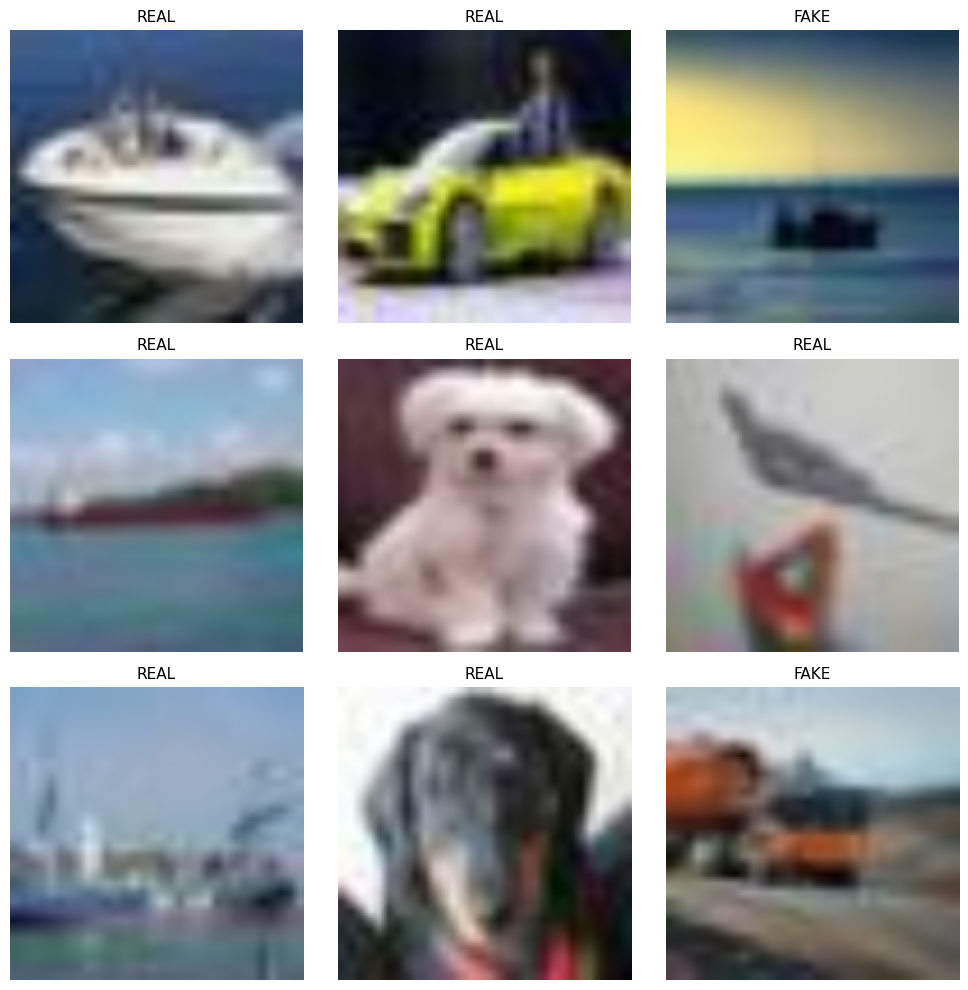

In [5]:
# Display 9 sample images with their labels
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train_raw.take(9)):
    plt.subplot(3, 3, i + 1)
    img = image.numpy().astype('uint8')
    plt.imshow(img)
    plt.title(CLASS_NAMES[label.numpy()], fontsize=11)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Προεπεξεργασια

- **Resize:** ηδη εγινε στο `image_dataset_from_directory` (128x128)
- **Normalize:** οι τιμες των pixels πανε απο [0, 255] σε [0, 1]
- **Data augmentation** (μονο στο training): random horizontal flip και brightness
- **Batch size:** 64 εικονες ανα batch
- **Prefetch:** το pipeline ετοιμαζει το επομενο batch οσο εκπαιδευεται το προηγουμενο

In [6]:
# Normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Data augmentation - applied only to training set
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Build the training pipeline (with augmentation + shuffle)
ds_train_prepared = (ds_train_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_val_prepared = (ds_val_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_test_prepared = (ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

print("Data pipelines ready")

Data pipelines ready


## 6. Κατασκευη του CNN (baseline)

Φτιαχνω ενα **custom CNN** απο την αρχη με 4 convolutional blocks. Καθε block εχει:
- **Conv2D:** ανιχνευει χαρακτηριστικα στην εικονα
- **BatchNormalization:** σταθεροποιει την εκπαιδευση
- **MaxPooling2D:** μειωνει τη διασταση της εικονας στο μισο

Στο τελος εχω **Dense(2)** με softmax για binary classification (REAL vs FAKE).

In [7]:
from tensorflow.keras import layers, models

# Build the custom CNN architecture
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,010 (1011.76 KB)

 Trainable params: 258,306 (1009.01 KB)

 Non-trainable params: 704 (2.75 KB)

## 7. Εκπαιδευση baseline

Εκπαιδευω για **10 epochs**. Καθε epoch θα παρει ~40 δευτερολεπτα στο Colab GPU (L4).

In [8]:
EPOCHS = 10

history = model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=EPOCHS
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.8721 - loss: 0.2990 - val_accuracy: 0.8953 - val_loss: 0.2551
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9240 - loss: 0.1962 - val_accuracy: 0.8815 - val_loss: 0.2821
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9327 - loss: 0.1730 - val_accuracy: 0.9340 - val_loss: 0.1729
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - accuracy: 0.9390 - loss: 0.1574 - val_accuracy: 0.9337 - val_loss: 0.1678
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9438 - loss: 0.1458 - val_accuracy: 0.9337 - val_loss: 0.1729
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9481 - loss: 0.1345 - val_accuracy: 0.9395 - val_loss: 0.1581
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9504 - loss: 0.1298 - val_accuracy: 0.9437 - val_loss: 0.1460
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9541 -

## 8. Καμπυλες εκπαιδευσης

Σχεδιαζω πως εξελιχθηκαν το **accuracy** και το **loss** σε train και validation set.

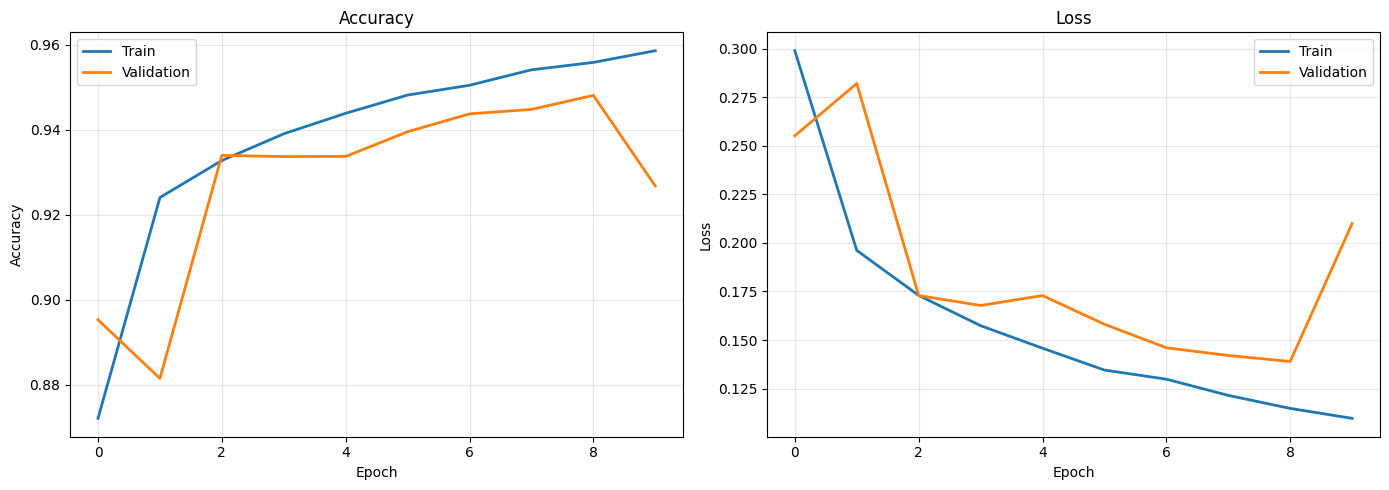

In [9]:
# Plot training and validation curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Αξιολογηση στο test set (baseline)

Υπολογιζω το τελικο **test accuracy** σε δεδομενα που το μοντελο δεν εχει ξαναδει.

In [10]:
# Final evaluation on the held-out test set
test_loss, test_acc = model.evaluate(ds_test_prepared, verbose=0)
print(f"Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"Baseline test loss:     {test_loss:.4f}")

Baseline test accuracy: 92.93%
Baseline test loss:     0.1995


## 10. Confusion Matrix

Στο binary classification ο πινακας ειναι 2x2:

| | Pred FAKE | Pred REAL |
|---|---|---|
| **True FAKE** | True Negative | False Positive |
| **True REAL** | False Negative | True Positive |

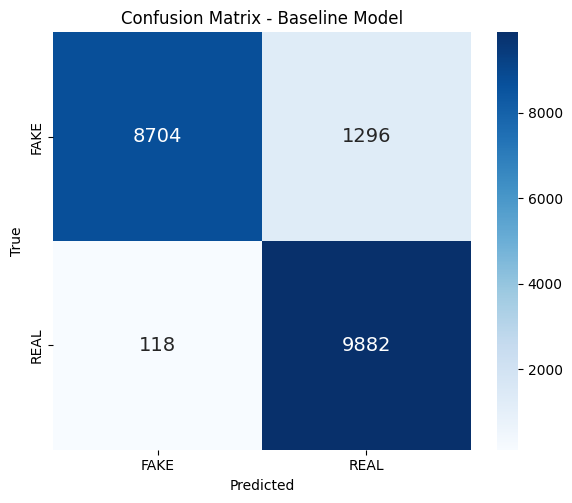

In [11]:
# Get predictions on the entire test set
y_true = []
y_pred = []

for images, labels in ds_test_prepared:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot 2x2 heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar=True, square=True, annot_kws={'fontsize': 14})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.show()

## 11. Παραδειγματα προβλεψεων

Δειχνω 9 τυχαιες εικονες απο το test set.
- **Πρασινος τιτλος:** σωστη προβλεψη
- **Κοκκινος τιτλος:** λαθος προβλεψη

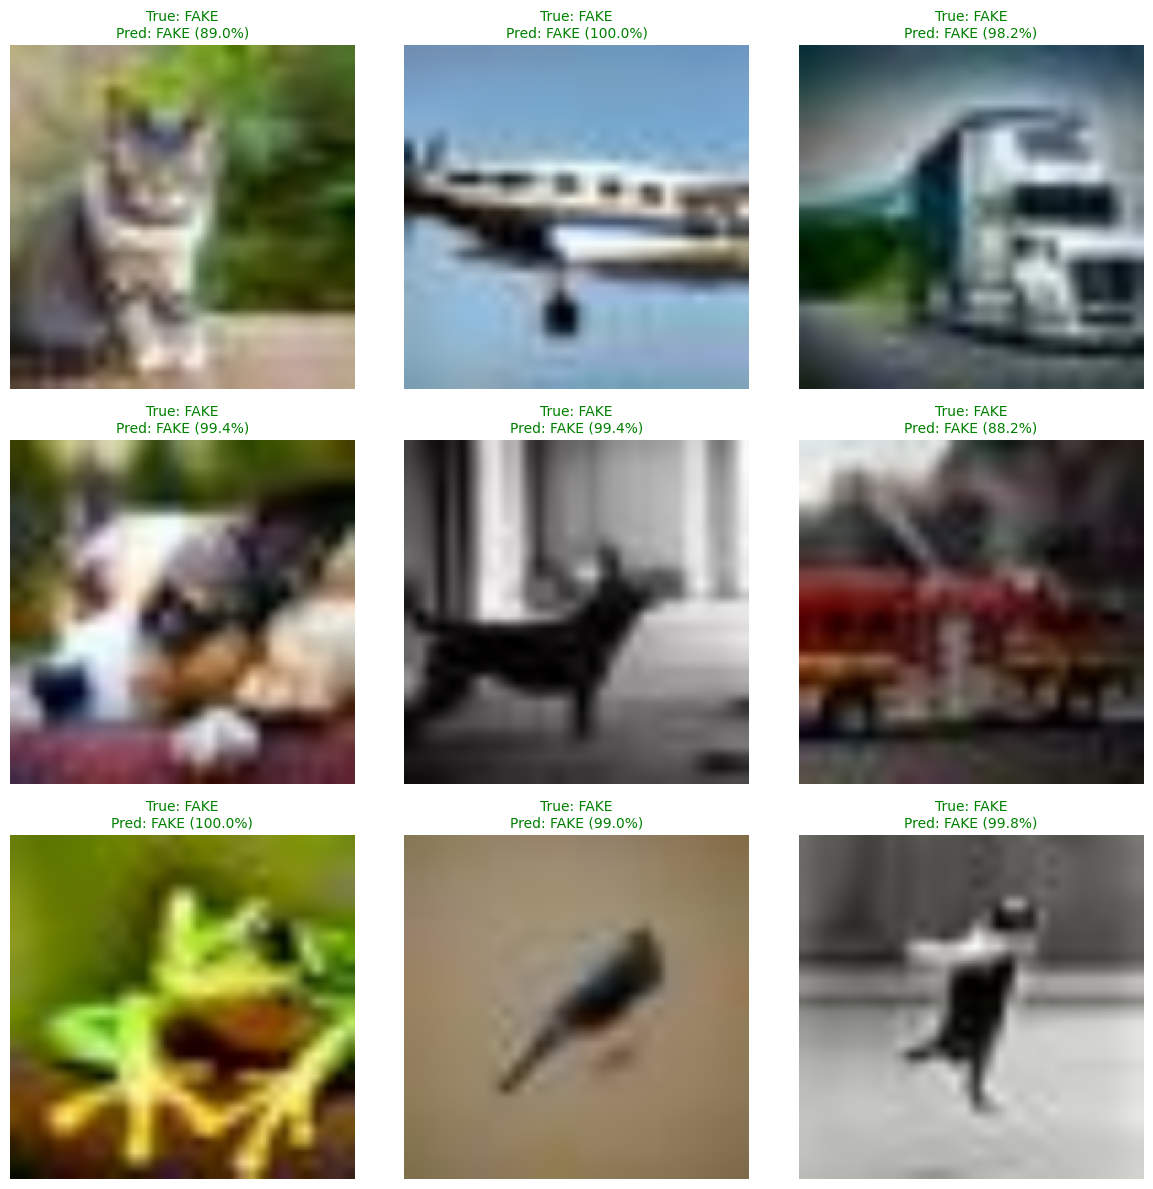

In [12]:
# Take one batch of test images and predict
for images, labels in ds_test_prepared.take(1):
    test_images = images.numpy()
    test_labels = labels.numpy()
    break

predictions = model.predict(test_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Show 9 random samples with predictions
indices = np.random.choice(len(test_images), 9, replace=False)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[idx])

    true_label = CLASS_NAMES[test_labels[idx]]
    pred_label = CLASS_NAMES[predicted_labels[idx]]
    confidence = predictions[idx][predicted_labels[idx]] * 100

    is_correct = test_labels[idx] == predicted_labels[idx]
    color = 'green' if is_correct else 'red'

    title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
    plt.title(title, fontsize=10, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning με Keras Tuner

Δοκιμαζω αυτοματα διαφορετικους συνδυασμους υπερπαραμετρων με **RandomSearch**.

| Hyperparameter | Τιμες προς δοκιμη |
|---|---|
| `dropout_rate` | 0.2, 0.3, 0.4, 0.5 |
| `dense_units` | 64, 128, 256 |
| `learning_rate` | 1e-3, 5e-4, 1e-4 |

In [13]:
!pip install -q keras-tuner

import keras_tuner as kt

print(f"Keras Tuner version: {kt.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00
Keras Tuner version: 1.4.8


### 12.1 Συναρτηση κατασκευης μοντελου με υπερπαραμετρους

In [14]:
def build_model(hp):
    # Define the search space
    dropout_rate = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_model function ready")

build_model function ready


### 12.2 Εκτελεση της αναζητησης

5 trials × 5 epochs ανα trial. Αναμενομενος χρονος: ~15 λεπτα.

In [15]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_results',
    project_name='deepfake_simple',
    overwrite=True
)

tuner.search_space_summary()

tuner.search(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=5,
    verbose=1
)

print("\nSearch complete!")

Trial 5 Complete [00h 03m 49s]
val_accuracy: 0.9477499723434448

Best val_accuracy So Far: 0.9484000205993652
Total elapsed time: 00h 19m 13s

Search complete!


### 12.3 Καλυτερες υπερπαραμετροι

In [16]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST HYPERPARAMETERS")
print("=" * 50)
print(f"  dropout_rate:  {best_hps.get('dropout')}")
print(f"  dense_units:   {best_hps.get('dense_units')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")
print("=" * 50)

print("\nAll trials summary:\n")
tuner.results_summary(num_trials=5)

BEST HYPERPARAMETERS
  dropout_rate:  0.2
  dense_units:   256
  learning_rate: 0.0001

All trials summary:

Results summary
Results in kt_results/deepfake_simple
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
dropout: 0.2
dense_units: 256
learning_rate: 0.0001
Score: 0.9484000205993652

Trial 0 summary
Hyperparameters:
dropout: 0.2
dense_units: 128
learning_rate: 0.001
Score: 0.947950005531311

Trial 4 summary
Hyperparameters:
dropout: 0.5
dense_units: 256
learning_rate: 0.0001
Score: 0.9477499723434448

Trial 1 summary
Hyperparameters:
dropout: 0.2
dense_units: 64
learning_rate: 0.001
Score: 0.9467499852180481

Trial 2 summary
Hyperparameters:
dropout: 0.3
dense_units: 128
learning_rate: 0.0001
Score: 0.9359999895095825


## 13. Εκπαιδευση του τελικου custom CNN

Με τις καλυτερες υπερπαραμετρους, εκπαιδευω για **15 epochs**.

In [17]:
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

history_best = best_model.fit(
    ds_train_prepared,
    validation_data=ds_val_prepared,
    epochs=15
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,778 (1.05 MB)

 Trainable params: 275,074 (1.05 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.8667 - loss: 0.3052 - val_accuracy: 0.9068 - val_loss: 0.2315
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9216 - loss: 0.1992 - val_accuracy: 0.9398 - val_loss: 0.1611
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9321 - loss: 0.1723 - val_accuracy: 0.9433 - val_loss: 0.1476
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9395 - loss: 0.1554 - val_accuracy: 0.9516 - val_loss: 0.1334
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9430 - loss: 0.1439 - val_accuracy: 0.9183 - val_loss: 0.2125
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9482 - loss: 0.1330 - val_accuracy: 0.9536 - val_loss: 0.1225
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9507 - loss: 0.1275 - val_accuracy: 0.9503 - val_loss: 0.1282
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9558 -

## 14. Συγκριση Baseline vs Tuned

  Baseline test accuracy: 92.93%
  Tuned    test accuracy: 95.56%
  Improvement:            +2.63%


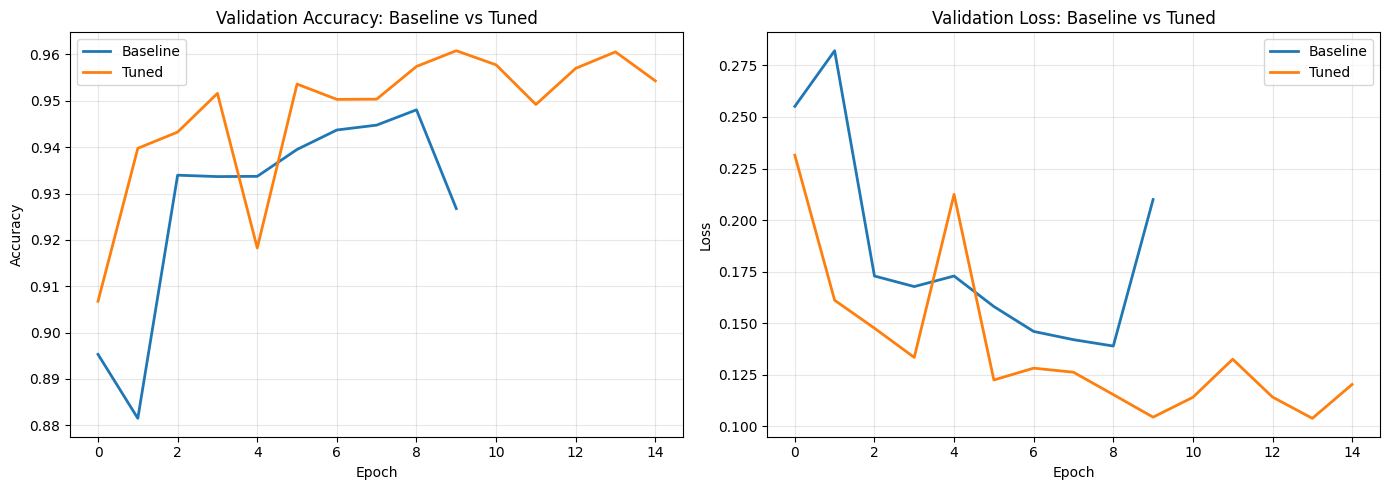

In [18]:
# Evaluate the tuned model on the test set
test_loss_best, test_acc_best = best_model.evaluate(ds_test_prepared, verbose=0)

print("=" * 55)
print(f"  Baseline test accuracy: {test_acc * 100:.2f}%")
print(f"  Tuned    test accuracy: {test_acc_best * 100:.2f}%")
print(f"  Improvement:            {(test_acc_best - test_acc) * 100:+.2f}%")
print("=" * 55)

# Plot comparison curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['val_accuracy'], label='Baseline', linewidth=2)
axes[0].plot(history_best.history['val_accuracy'], label='Tuned', linewidth=2)
axes[0].set_title('Validation Accuracy: Baseline vs Tuned')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['val_loss'], label='Baseline', linewidth=2)
axes[1].plot(history_best.history['val_loss'], label='Tuned', linewidth=2)
axes[1].set_title('Validation Loss: Baseline vs Tuned')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Transfer Learning με ResNet50

Δοκιμαζω **transfer learning** με το ResNet50 (50 layers, pretrained σε ImageNet).
- Παγωνω (freeze) το backbone
- Προσθετω δικο μου classification head
- Το ResNet50 χρειαζεται εικονες **224x224** και ειδικη preprocessing

In [19]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

IMG_SIZE_RESNET = 224

# ResNet-specific preprocessing (NOT /255 - has its own normalization)
def preprocess_resnet(image, label):
    image = tf.image.resize(image, (IMG_SIZE_RESNET, IMG_SIZE_RESNET))
    image = resnet_preprocess(tf.cast(image, tf.float32))
    return image, label

# Build new pipelines for ResNet
ds_train_resnet = (ds_train_raw
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_val_resnet = (ds_val_raw
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

ds_test_resnet = (ds_test_raw
    .map(preprocess_resnet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

print("ResNet50 data pipelines ready")

ResNet50 data pipelines ready


### 15.1 Κατασκευη ResNet50 baseline

In [20]:
from tensorflow.keras.applications import ResNet50

# Load pretrained ResNet50 (without the top classification layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3)
)

# Freeze the backbone
base_model.trainable = False

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 15.2 Εκπαιδευση ResNet50 baseline

In [21]:
history_resnet = model_resnet.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=10
)

test_loss_resnet, test_acc_resnet = model_resnet.evaluate(ds_test_resnet, verbose=0)
print(f"\nResNet50 baseline test accuracy: {test_acc_resnet * 100:.2f}%")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 104ms/step - accuracy: 0.9132 - loss: 0.2153 - val_accuracy: 0.9394 - val_loss: 0.1514
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9415 - loss: 0.1493 - val_accuracy: 0.9529 - val_loss: 0.1207
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9482 - loss: 0.1337 - val_accuracy: 0.9572 - val_loss: 0.1128
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9528 - loss: 0.1218 - val_accuracy: 0.9573 - val_loss: 0.1098
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9568 - loss: 0.1113 - val_accuracy: 0.9606 - val_loss: 0.1051
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9586 - loss: 0.1074 - val_accuracy: 0.9646 - val_loss: 0.0942
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9615 - loss: 0.1009 - val_accuracy: 0.9625 - val_loss: 0.0992
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy:

## 16. ResNet50 με Hyperparameter Tuning

In [22]:
def build_resnet_model(hp):
    dropout_rate = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    backbone = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_RESNET, IMG_SIZE_RESNET, 3)
    )
    backbone.trainable = False

    model = models.Sequential([
        backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner_resnet = kt.RandomSearch(
    build_resnet_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_results_resnet',
    project_name='deepfake_resnet',
    overwrite=True
)

tuner_resnet.search_space_summary()

tuner_resnet.search(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=5,
    verbose=1
)

print("\nResNet tuning complete!")

Trial 5 Complete [00h 10m 36s]
val_accuracy: 0.9559999704360962

Best val_accuracy So Far: 0.9608500003814697
Total elapsed time: 00h 53m 01s

ResNet tuning complete!


### 16.1 Καλυτερες υπερπαραμετροι για ResNet

In [23]:
best_hps_resnet = tuner_resnet.get_best_hyperparameters(num_trials=1)[0]

print("=" * 50)
print("BEST RESNET HYPERPARAMETERS")
print("=" * 50)
print(f"  dropout_rate:  {best_hps_resnet.get('dropout')}")
print(f"  dense_units:   {best_hps_resnet.get('dense_units')}")
print(f"  learning_rate: {best_hps_resnet.get('learning_rate')}")
print("=" * 50)

print("\nAll trials summary:\n")
tuner_resnet.results_summary(num_trials=5)

BEST RESNET HYPERPARAMETERS
  dropout_rate:  0.3
  dense_units:   128
  learning_rate: 0.0001

All trials summary:

Results summary
Results in kt_results_resnet/deepfake_resnet
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
dropout: 0.3
dense_units: 128
learning_rate: 0.0001
Score: 0.9608500003814697

Trial 3 summary
Hyperparameters:
dropout: 0.4
dense_units: 64
learning_rate: 0.0005
Score: 0.9602500200271606

Trial 0 summary
Hyperparameters:
dropout: 0.2
dense_units: 64
learning_rate: 0.0001
Score: 0.9592000246047974

Trial 2 summary
Hyperparameters:
dropout: 0.5
dense_units: 64
learning_rate: 0.001
Score: 0.9570000171661377

Trial 4 summary
Hyperparameters:
dropout: 0.4
dense_units: 64
learning_rate: 0.0001
Score: 0.9559999704360962


### 16.2 Εκπαιδευση τελικου ResNet μοντελου

In [24]:
best_model_resnet = tuner_resnet.hypermodel.build(best_hps_resnet)

history_resnet_best = best_model_resnet.fit(
    ds_train_resnet,
    validation_data=ds_val_resnet,
    epochs=15
)

test_loss_resnet_best, test_acc_resnet_best = best_model_resnet.evaluate(ds_test_resnet, verbose=0)
print(f"\nResNet50 tuned test accuracy: {test_acc_resnet_best * 100:.2f}%")

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 103ms/step - accuracy: 0.8910 - loss: 0.2590 - val_accuracy: 0.9402 - val_loss: 0.1551
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9401 - loss: 0.1536 - val_accuracy: 0.9502 - val_loss: 0.1284
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9492 - loss: 0.1285 - val_accuracy: 0.9577 - val_loss: 0.1148
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9565 - loss: 0.1136 - val_accuracy: 0.9584 - val_loss: 0.1082
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9609 - loss: 0.1034 - val_accuracy: 0.9590 - val_loss: 0.1063
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9643 - loss: 0.0941 - val_accuracy: 0.9624 - val_loss: 0.0997
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.9675 - loss: 0.0865 - val_accuracy: 0.9597 - val_loss: 0.1062
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy:

## 17. Τελικη συγκριση και των 4 μοντελων

1. **Simple CNN (baseline)**
2. **Simple CNN (tuned)**
3. **ResNet50 (baseline)**
4. **ResNet50 (tuned)**

Model                          Test Accuracy
Simple CNN (baseline)                 92.93%
Simple CNN (tuned)                    95.56%
ResNet50 (baseline)                   96.29%
ResNet50 (tuned)                      96.50%

Best model: ResNet50 (tuned) (96.50%)


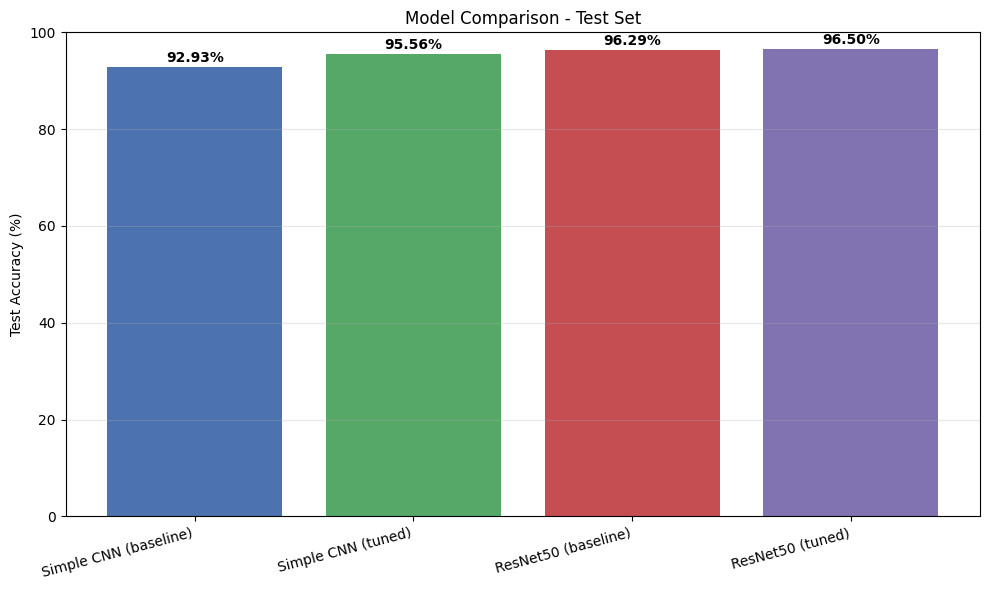

In [25]:
# Comparison table + bar chart
results = {
    'Simple CNN (baseline)':  test_acc,
    'Simple CNN (tuned)':     test_acc_best,
    'ResNet50 (baseline)':    test_acc_resnet,
    'ResNet50 (tuned)':       test_acc_resnet_best,
}

print("=" * 55)
print(f"{'Model':<28} {'Test Accuracy':>15}")
print("=" * 55)
for name, acc in results.items():
    print(f"{name:<28} {acc * 100:>14.2f}%")
print("=" * 55)
best_name = max(results, key=results.get)
print(f"\nBest model: {best_name} ({results[best_name] * 100:.2f}%)")

# Bar chart
plt.figure(figsize=(10, 6))
names = list(results.keys())
accs = [v * 100 for v in results.values()]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(names, accs, color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison - Test Set')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 17.1 Συγκριση καμπυλων validation accuracy

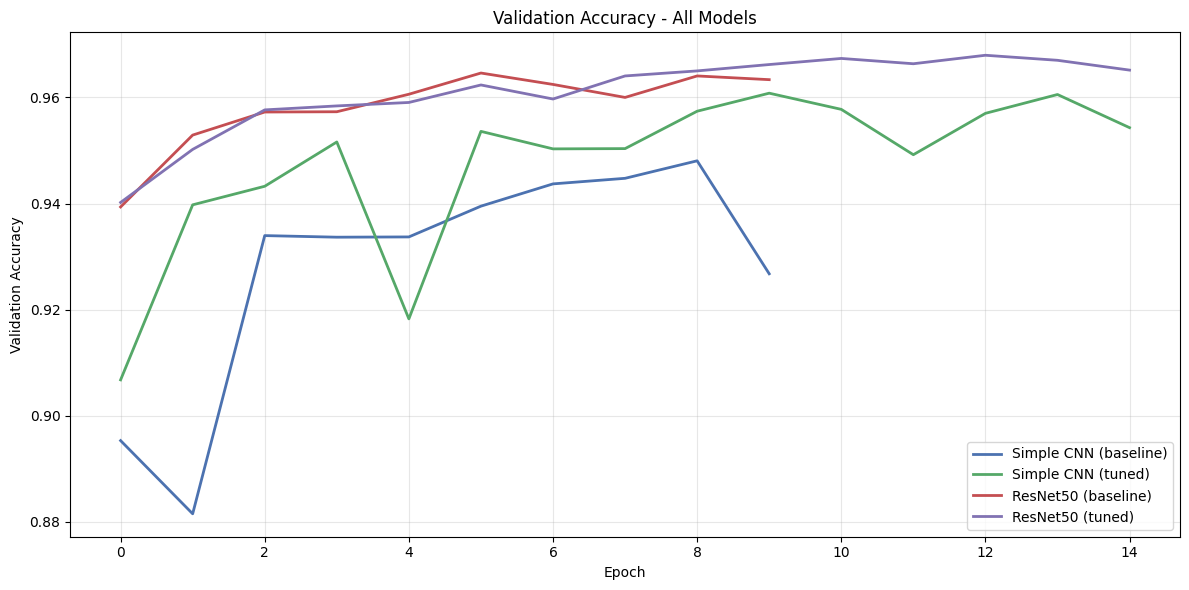

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(history.history['val_accuracy'],
         label='Simple CNN (baseline)', linewidth=2, color='#4C72B0')
plt.plot(history_best.history['val_accuracy'],
         label='Simple CNN (tuned)', linewidth=2, color='#55A868')
plt.plot(history_resnet.history['val_accuracy'],
         label='ResNet50 (baseline)', linewidth=2, color='#C44E52')
plt.plot(history_resnet_best.history['val_accuracy'],
         label='ResNet50 (tuned)', linewidth=2, color='#8172B2')

plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Συλλογη μετρικων και εξαγωγη σε JSON

Πεαρ απο accuracy, μαζευω και αλλες σημαντικες μετρικες απο τα 4 μοντελα και τα εξαγω σε ενα JSON αρχειο για περαιτερω αναλυση.

**Τι θα συλλεξω για καθε μοντελο:**

*Standard:*
- Test accuracy / Test loss
- **Top-3** και **Top-5** accuracy (για binary δεν εχει νοημα, παραλειπεται αυτοματα)

*Aggregate:*
- **Precision / Recall / F1** (macro και weighted)

*Ανθεκτικες σε class imbalance:*
- **Cohen's Kappa**
- **Matthews Correlation Coefficient (MCC)**
- **Balanced Accuracy**

*Πιθανοτητες:*
- **ROC-AUC** (για binary: το standard AUC)
- **Log loss** (cross-entropy)

*Confidence analysis:*
- Μεσο **confidence** σε σωστες vs λαθος προβλεψεις

*Per-class detail:*
- Classification report
- Per-class accuracy και support
- Confusion matrix

*Speed & size:*
- Inference time ανα sample (ms)
- Number of parameters

*Training:*
- Training history και ολα τα tuner trials

### 18.1 Συναρτηση συλλογης μετρικων

In [27]:
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score, roc_auc_score, log_loss
)
import time

def collect_metrics(model, ds_test, model_name):
    """Run predictions on the test set and gather a rich set of metrics."""
    y_true_local, y_pred_local, y_proba_local = [], [], []

    start_time = time.time()
    n_samples = 0

    for images, labels in ds_test:
        proba = model.predict(images, verbose=0)
        y_true_local.extend(labels.numpy())
        y_pred_local.extend(np.argmax(proba, axis=1))
        y_proba_local.extend(proba)
        n_samples += len(labels.numpy())

    inference_time_total = time.time() - start_time
    inference_time_per_sample_ms = (inference_time_total / n_samples) * 1000

    y_true_arr = np.array(y_true_local)
    y_pred_arr = np.array(y_pred_local)
    y_proba_arr = np.array(y_proba_local)

    # Test loss/accuracy
    test_loss_m, test_acc_m = model.evaluate(ds_test, verbose=0)

    # Classification report
    report = classification_report(
        y_true_arr, y_pred_arr,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    macro_avg = report['macro avg']
    weighted_avg = report['weighted avg']

    # Per-class accuracy and support
    per_class_acc, per_class_support = {}, {}
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        mask = y_true_arr == cls_idx
        per_class_support[cls_name] = int(mask.sum())
        per_class_acc[cls_name] = float((y_pred_arr[mask] == cls_idx).mean()) if mask.sum() > 0 else None

    # Confusion matrix
    cm = confusion_matrix(y_true_arr, y_pred_arr).tolist()

    # Robust metrics for class imbalance
    kappa = cohen_kappa_score(y_true_arr, y_pred_arr)
    mcc = matthews_corrcoef(y_true_arr, y_pred_arr)
    bal_acc = balanced_accuracy_score(y_true_arr, y_pred_arr)

    # ROC-AUC (binary uses positive class probability)
    try:
        roc_auc = float(roc_auc_score(y_true_arr, y_proba_arr[:, 1]))
    except Exception:
        roc_auc = None

    # Log loss
    try:
        ll = float(log_loss(y_true_arr, y_proba_arr, labels=list(range(NUM_CLASSES))))
    except Exception:
        ll = None

    # Confidence analysis
    confidences = np.max(y_proba_arr, axis=1)
    correct_mask = (y_pred_arr == y_true_arr)
    mean_conf_overall = float(confidences.mean())
    mean_conf_correct = float(confidences[correct_mask].mean()) if correct_mask.sum() > 0 else None
    mean_conf_incorrect = float(confidences[~correct_mask].mean()) if (~correct_mask).sum() > 0 else None

    trainable = int(sum(np.prod(v.shape) for v in model.trainable_variables))

    return {
        'name': model_name,
        'test_accuracy': float(test_acc_m),
        'test_loss': float(test_loss_m),
        'precision_macro': float(macro_avg['precision']),
        'recall_macro': float(macro_avg['recall']),
        'f1_macro': float(macro_avg['f1-score']),
        'precision_weighted': float(weighted_avg['precision']),
        'recall_weighted': float(weighted_avg['recall']),
        'f1_weighted': float(weighted_avg['f1-score']),
        'cohen_kappa': float(kappa),
        'matthews_corrcoef': float(mcc),
        'balanced_accuracy': float(bal_acc),
        'roc_auc': roc_auc,
        'log_loss': ll,
        'mean_confidence': mean_conf_overall,
        'mean_confidence_correct': mean_conf_correct,
        'mean_confidence_incorrect': mean_conf_incorrect,
        'inference_time_total_sec': float(inference_time_total),
        'inference_time_per_sample_ms': float(inference_time_per_sample_ms),
        'num_test_samples': int(n_samples),
        'classification_report': report,
        'per_class_accuracy': per_class_acc,
        'per_class_support': per_class_support,
        'confusion_matrix': cm,
        'num_total_params': int(model.count_params()),
        'num_trainable_params': trainable,
    }

print("collect_metrics function ready")

collect_metrics function ready


### 18.2 Συλλογη μετρικων για τα 4 μοντελα

In [28]:
print("Collecting metrics for Simple CNN (baseline)...")
metrics_simple = collect_metrics(model, ds_test_prepared, 'Simple CNN (baseline)')

print("Collecting metrics for Simple CNN (tuned)...")
metrics_simple_tuned = collect_metrics(best_model, ds_test_prepared, 'Simple CNN (tuned)')

print("Collecting metrics for ResNet50 (baseline)...")
metrics_resnet = collect_metrics(model_resnet, ds_test_resnet, 'ResNet50 (baseline)')

print("Collecting metrics for ResNet50 (tuned)...")
metrics_resnet_tuned = collect_metrics(best_model_resnet, ds_test_resnet, 'ResNet50 (tuned)')

all_metrics = [metrics_simple, metrics_simple_tuned, metrics_resnet, metrics_resnet_tuned]

print("\n" + "=" * 110)
print(f"{'Model':<26} {'Acc':>7} {'F1-mac':>8} {'Kappa':>7} {'MCC':>7} {'BalAcc':>8} {'AUC':>8} {'ms/img':>8}")
print("=" * 110)
for m in all_metrics:
    print(f"{m['name']:<26} "
          f"{m['test_accuracy']*100:>6.2f}% "
          f"{m['f1_macro']:>8.4f} "
          f"{m['cohen_kappa']:>7.4f} "
          f"{m['matthews_corrcoef']:>7.4f} "
          f"{m['balanced_accuracy']:>8.4f} "
          f"{(m['roc_auc'] or 0):>8.4f} "
          f"{m['inference_time_per_sample_ms']:>7.2f}")
print("=" * 110)
print("\nConfidence analysis:")
print(f"{'Model':<26} {'Overall':>10} {'On Correct':>12} {'On Incorrect':>14}")
for m in all_metrics:
    print(f"{m['name']:<26} "
          f"{m['mean_confidence']*100:>9.2f}% "
          f"{(m['mean_confidence_correct'] or 0)*100:>11.2f}% "
          f"{(m['mean_confidence_incorrect'] or 0)*100:>13.2f}%")


Model                          Acc   F1-mac   Kappa     MCC   BalAcc      AUC   ms/img
Simple CNN (baseline)       92.93%   0.9291  0.8586  0.8646   0.9293   0.9922    1.30
Simple CNN (tuned)          95.56%   0.9556  0.9113  0.9127   0.9556   0.9937    1.34
ResNet50 (baseline)         96.29%   0.9629  0.9259  0.9260   0.9629   0.9939    2.76
ResNet50 (tuned)            96.50%   0.9650  0.9301  0.9304   0.9650   0.9952    2.69

Confidence analysis:
Model                         Overall   On Correct   On Incorrect
Simple CNN (baseline)          95.67%       96.85%         80.22%
Simple CNN (tuned)             96.40%       97.29%         77.06%
ResNet50 (baseline)            96.92%       97.68%         77.28%
ResNet50 (tuned)               97.19%       97.90%         77.74%


### 18.3 Δομηση πληρους dictionary

In [29]:
import json
from datetime import datetime

def history_to_floats(hist_dict):
    return {k: [float(v) for v in vals] for k, vals in hist_dict.items()}

def collect_tuner_trials(tuner_obj):
    trials = []
    for trial_id, trial in tuner_obj.oracle.trials.items():
        trials.append({
            'trial_id': trial_id,
            'score': float(trial.score) if trial.score is not None else None,
            'hyperparameters': dict(trial.hyperparameters.values),
        })
    trials.sort(key=lambda t: (t['score'] is None, -(t['score'] or 0)))
    return trials

all_results = {
    'metadata': {
        'dataset': 'CIFAKE',
        'task': 'binary classification: REAL vs FAKE (AI-generated)',
        'num_classes': int(NUM_CLASSES),
        'class_names': list(CLASS_NAMES),
        'image_size_simple_cnn': IMG_SIZE,
        'image_size_resnet': IMG_SIZE_RESNET,
        'batch_size': BATCH_SIZE,
        'tf_version': tf.__version__,
        'timestamp': datetime.now().isoformat(),
    },
    'models': {
        'simple_baseline': {
            **metrics_simple,
            'history': history_to_floats(history.history),
            'epochs_trained': len(history.history['accuracy']),
            'hyperparameters': {'dropout': 0.4, 'dense_units': 128, 'learning_rate': 1e-3, 'optimizer': 'Adam'},
        },
        'simple_tuned': {
            **metrics_simple_tuned,
            'history': history_to_floats(history_best.history),
            'epochs_trained': len(history_best.history['accuracy']),
            'hyperparameters': {
                'dropout': float(best_hps.get('dropout')),
                'dense_units': int(best_hps.get('dense_units')),
                'learning_rate': float(best_hps.get('learning_rate')),
                'optimizer': 'Adam',
            },
        },
        'resnet_baseline': {
            **metrics_resnet,
            'history': history_to_floats(history_resnet.history),
            'epochs_trained': len(history_resnet.history['accuracy']),
            'hyperparameters': {'dropout': 0.4, 'dense_units': 128, 'learning_rate': 1e-3, 'optimizer': 'Adam', 'backbone_frozen': True},
        },
        'resnet_tuned': {
            **metrics_resnet_tuned,
            'history': history_to_floats(history_resnet_best.history),
            'epochs_trained': len(history_resnet_best.history['accuracy']),
            'hyperparameters': {
                'dropout': float(best_hps_resnet.get('dropout')),
                'dense_units': int(best_hps_resnet.get('dense_units')),
                'learning_rate': float(best_hps_resnet.get('learning_rate')),
                'optimizer': 'Adam',
                'backbone_frozen': True,
            },
        },
    },
    'tuner_trials': {
        'simple_cnn': collect_tuner_trials(tuner),
        'resnet': collect_tuner_trials(tuner_resnet),
    },
}

print("Full results dictionary built")
print(f"  Top-level keys: {list(all_results.keys())}")
print(f"  Models tracked: {list(all_results['models'].keys())}")

Full results dictionary built
  Top-level keys: ['metadata', 'models', 'tuner_trials']
  Models tracked: ['simple_baseline', 'simple_tuned', 'resnet_baseline', 'resnet_tuned']


### 18.4 Εξαγωγη σε JSON και download

In [30]:
import os, json

output_filename = 'deepfake_results.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(output_filename) / 1024
print(f"Saved results to '{output_filename}' ({size_kb:.1f} KB)")

try:
    from google.colab import files
    files.download(output_filename)
    print("Download started in Colab")
except ImportError:
    print(f"Not running in Colab. File saved at: {os.path.abspath(output_filename)}")

Saved results to 'deepfake_results.json' (17.6 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in Colab


## Συμπερασματα

Εχτισα και συγκρινα **4 μοντελα** για ανιχνευση AI-generated εικονων (CIFAKE dataset):

1. **Simple CNN (baseline)** - 4 conv blocks, χειροκινητες υπερπαραμετροι
2. **Simple CNN (tuned)** - tuned με RandomSearch
3. **ResNet50 (baseline)** - transfer learning με frozen ImageNet backbone
4. **ResNet50 (tuned)** - tuned classification head πανω σε frozen ResNet50

**Τι εκανα:**
- Χρησ/σα CIFAKE dataset (real images vs Stable Diffusion generated)
- Σχεδιασα custom CNN αρχιτεκτονικη απο την αρχη
- Εκανα data augmentation
- Εφαρμοσα transfer learning με ResNet50
- Εκανα hyperparameter tuning με Keras Tuner RandomSearch
- Συλλεξα ολες τις σημαντικες μετρικες (accuracy, F1, MCC, Kappa, AUC, log loss)
- Εξηγαγα τα αποτελεσματα σε JSON για περαιτερω αναλυση

**Επομενα βηματα:**
- Fine-tuning των τελευταιων layers του ResNet50
- Δοκιμη με αλλα pretrained models (EfficientNet, ViT)
- Πιο επιθετικο data augmentation
- Δοκιμη σε newer deepfake datasets (FaceForensics++, DFDC)